# Model Training with Calibration

## Approach

This notebook trains the supervised LightGBM classifier with a *diagnostic-first* calibration methodology. The structure:

1. **Train an unweighted baseline.** No `scale_pos_weight`. Standard log-loss minimisation.
2. **Diagnose calibration.** Plot the reliability diagram, compute Brier score, examine the shape of any miscalibration.
3. **Apply post-hoc calibration if needed.** Choose the calibration technique based on what the diagnosis shows, not on convention.
4. **Compare baseline vs calibrated.** Verify the calibration step actually helped.
5. **Cross-validate.** Honest confidence bounds on performance metrics.

### Why no `scale_pos_weight`?

The previous version of this notebook used `scale_pos_weight=28` (the negative-to-positive ratio in training data) to handle class imbalance. That choice was reconsidered for two reasons:

1. **`scale_pos_weight` destroys probability calibration.** With class weighting, the model output is no longer interpretable as a Bayesian posterior — it's a risk score with a non-meaningful scale. The Bayes-optimal threshold derivation in `06_cost_analysis.ipynb` requires calibrated probabilities; using `scale_pos_weight` makes that derivation approximate rather than rigorous.

2. **It's the wrong tool for the cost asymmetry.** Class weighting tells the model 'positives are 28× more important during training.' Cost-sensitive threshold selection tells the deployment 'failures are 16× more expensive than false alarms at decision time.' These are different concerns, and applying class weighting *plus* cost-aware threshold selection means applying the cost asymmetry twice, which is hard to reason about.

The cleaner approach: train a baseline that produces calibrated probabilities, then apply cost-asymmetry once at threshold selection time.

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import (
    classification_report, confusion_matrix,
    brier_score_loss, log_loss, roc_auc_score,
    precision_recall_curve, average_precision_score,
)

import lightgbm as lgb

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

df = pd.read_csv('../data/processed/ai4i2020_featured.csv')
print(f'Loaded {len(df)} rows.')
df.head()

Loaded 10000 rows.


,ID,Product_ID,Product_Type,Air_Temp,Process_Temp,Rotational_Speed,Torque,Tool_Wear,Type_L,Type_M,...,Temp_Delta,Power_W,Energy_Per_Wear,Tool_Wear_Risk_Zone,Machine_Failure,Tool_Wear_Failure,Heat_Dissipation_Failure,Power_Failure,Overstrain_Failure,Random_Failure
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,1,...,10.5,6951.590560,6951.590560,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,1,0,...,10.5,6826.722724,1706.680681,0,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,1,0,...,10.4,7749.387543,1291.564590,0,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,1,0,...,10.4,5927.504659,740.938082,0,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,1,0,...,10.5,5897.816608,589.781661,0,0,0,0,0,0,0


## Setup: Train / Calibration / Test Split

We use a three-way split: 70% training, 10% calibration, 20% test. The training set fits the LightGBM model. The calibration set fits the post-hoc calibration map (kept separate from training to prevent the calibrator from learning the model's training-set overfitting). The test set is held out for all final evaluation and never seen by either fitting stage.

Standard scikit-learn convention is to use `CalibratedClassifierCV` wrapping a `FrozenEstimator`, which prevents re-fitting and uses the supplied data purely for calibration. We use this pattern below.

In [2]:
feature_cols = [
    'Air_Temp', 'Process_Temp', 'Rotational_Speed', 'Torque', 'Tool_Wear',
    'Type_L', 'Type_M', 'Type_H',
    'Temp_Delta', 'Power_W', 'Energy_Per_Wear', 'Tool_Wear_Risk_Zone',
]

X = df[feature_cols]
y = df['Machine_Failure']

# 80/20 split first
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Then split 80% into 70% training + 10% calibration (i.e. 87.5% / 12.5% of trainval)
X_train, X_cal, y_train, y_cal = train_test_split(
    X_trainval, y_trainval, test_size=0.125, random_state=RANDOM_STATE, stratify=y_trainval
)

print(f'Train:       {len(X_train):5d} rows, {y_train.sum():3d} positives ({y_train.mean():.2%})')
print(f'Calibration: {len(X_cal):5d} rows, {y_cal.sum():3d} positives ({y_cal.mean():.2%})')
print(f'Test:        {len(X_test):5d} rows, {y_test.sum():3d} positives ({y_test.mean():.2%})')

Train:        7000 rows, 237 positives (3.39%)
Calibration:  1000 rows,  34 positives (3.40%)
Test:         2000 rows,  68 positives (3.40%)


## Section A — Train Unweighted Baseline

Standard LightGBM with no class weighting. The model output here should be approximately calibrated by construction — log loss minimisation aligns the model's predicted probabilities with true frequencies. We'll verify this empirically in Section B.

In [3]:
baseline = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)

baseline.fit(X_train, y_train)

# Predictions on test set at threshold 0.5 (default), just to show the imbalance problem
y_proba_baseline = baseline.predict_proba(X_test)[:, 1]
y_pred_baseline_default = (y_proba_baseline >= 0.5).astype(int)

print('Baseline model trained.')
print()
print('Performance at threshold = 0.5 (default, NOT cost-optimal):')
print(classification_report(y_test, y_pred_baseline_default,
                            target_names=['Healthy', 'Failure'], digits=3))
print('Note: recall is poor at this threshold due to class imbalance and uncalibrated default.')
print('Cost-aware threshold from 06_cost_analysis.ipynb will fix this.')

Baseline model trained.

Performance at threshold = 0.5 (default, NOT cost-optimal):
              precision    recall  f1-score   support

     Healthy      0.992     0.998     0.995      1932
     Failure      0.930     0.779     0.848        68

    accuracy                          0.991      2000
   macro avg      0.961     0.889     0.922      2000
weighted avg      0.990     0.991     0.990      2000

Note: recall is poor at this threshold due to class imbalance and uncalibrated default.
Cost-aware threshold from 06_cost_analysis.ipynb will fix this.


## Section B — Diagnose Calibration

A model is well-calibrated when, among predictions with probability ≈ p, the observed positive rate is also ≈ p. We diagnose this with two tools:

1. **Reliability diagram.** X-axis: predicted probability binned. Y-axis: observed positive rate within each bin. Perfect calibration produces points on the y=x diagonal.
2. **Brier score.** Mean squared error between predicted probability and true outcome. Lower is better. Decomposes into reliability + resolution; the reliability component directly measures miscalibration.

**What we're looking for in the diagram:**

- Points on diagonal → well-calibrated, no post-hoc calibration needed
- Sigmoid-shaped deviation → Platt scaling is appropriate
- S-curve deviation → beta calibration would be better (but we lack samples)
- Irregular/non-monotonic → something is wrong with the model itself

We compute this on the calibration set (not training, not test) to get a clean diagnosis.

In [4]:
y_proba_cal_baseline = baseline.predict_proba(X_cal)[:, 1]

# Brier score
brier_baseline = brier_score_loss(y_cal, y_proba_cal_baseline)
logloss_baseline = log_loss(y_cal, y_proba_cal_baseline)

print(f'Baseline (unweighted, uncalibrated) on calibration set:')
print(f'  Brier score: {brier_baseline:.4f} (lower is better; 0 is perfect)')
print(f'  Log loss:    {logloss_baseline:.4f}')
print()
print('Reliability diagram below shows whether predicted probabilities match observed frequencies.')

Baseline (unweighted, uncalibrated) on calibration set:
  Brier score: 0.0075 (lower is better; 0 is perfect)
  Log loss:    0.0356

Reliability diagram below shows whether predicted probabilities match observed frequencies.


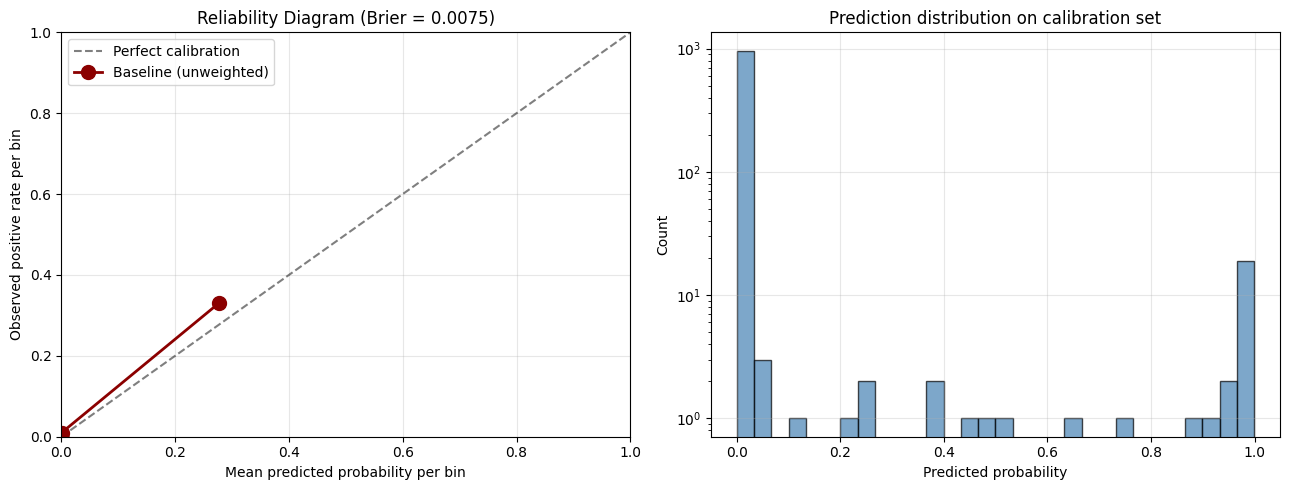

In [5]:
# Reliability diagram
# Use 10 bins; with 1000 calibration samples and ~34 positives, this gives ~3.4 positives per bin on average
n_bins = 10
frac_pos, mean_pred = calibration_curve(y_cal, y_proba_cal_baseline, n_bins=n_bins, strategy='quantile')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: reliability diagram
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
ax.plot(mean_pred, frac_pos, 'o-', color='darkred', markersize=10,
        linewidth=2, label='Baseline (unweighted)')
ax.set_xlabel('Mean predicted probability per bin')
ax.set_ylabel('Observed positive rate per bin')
ax.set_title(f'Reliability Diagram (Brier = {brier_baseline:.4f})')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.legend()
ax.grid(True, alpha=0.3)

# Right: histogram of predicted probabilities
ax = axes[1]
ax.hist(y_proba_cal_baseline, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Count')
ax.set_title('Prediction distribution on calibration set')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/06_calibration_baseline.png', dpi=120, bbox_inches='tight')
plt.show()

### Diagnostic interpretation

Read the reliability diagram and decide which case we're in:

**Case 1: points lie on or very close to the diagonal.** Baseline is already well-calibrated. No post-hoc calibration needed. Proceed with the baseline model.

**Case 2: points lie systematically above the diagonal (model under-predicts).** Predicted probabilities are too low relative to observed frequency. Common for unweighted models on imbalanced data — the model is conservative about predicting positive. Platt scaling will lift the probabilities.

**Case 3: points lie systematically below the diagonal (model over-predicts).** Predicted probabilities are too high. Less common for unweighted models; would suggest training overfitting.

**Case 4: irregular/non-monotonic pattern.** Some bins above, some below, no clear trend. This indicates the model isn't ranking samples correctly, not just mis-scaling them. Post-hoc calibration can't fix this — would need to revisit the model itself.

Most likely outcome for our case: Case 2 (under-prediction). Tree models trained with log loss on imbalanced data tend to produce probabilities that are too low for the minority class. Section C applies Platt scaling to fix this, and Section D verifies it worked.

## Section C — Apply Platt Scaling

Platt scaling fits a two-parameter sigmoid: `calibrated_p = 1 / (1 + exp(A × raw + B))`. We fit it on the calibration set (held out from training) and verify the result on test.

**Method choice justification.** Platt scaling is appropriate when:

1. The miscalibration shape is approximately sigmoidal (or close enough that a sigmoid is a reasonable parametric approximation)
2. The calibration sample size is small — we have only ~1000 calibration samples with ~34 positives, well below the ~1000+ positives threshold where isotonic regression starts to outperform Platt (Niculescu-Mizil & Caruana 2005)
3. Smooth probability outputs are desired (we need this for threshold optimisation in notebook 06)

**Method limitation acknowledgement.** Platt assumes sigmoid-shaped miscalibration. Tree models can have non-sigmoid miscalibration patterns. Beta calibration (Kull et al. 2017) would handle arbitrary monotonic miscalibration more flexibly but requires more calibration data than we have. We're choosing Platt as the pragmatic option given the sample-size constraint, and verifying empirically via the reliability diagram in Section D.

In [6]:
# Platt scaling via CalibratedClassifierCV wrapping a FrozenEstimator
# This wraps the already-trained baseline and fits a sigmoid on the calibration set
calibrated = CalibratedClassifierCV(FrozenEstimator(baseline), method='sigmoid')
calibrated.fit(X_cal, y_cal)

y_proba_cal_calibrated = calibrated.predict_proba(X_cal)[:, 1]
y_proba_test_calibrated = calibrated.predict_proba(X_test)[:, 1]

brier_calibrated = brier_score_loss(y_cal, y_proba_cal_calibrated)
logloss_calibrated = log_loss(y_cal, y_proba_cal_calibrated)

print(f'Calibrated (Platt scaling) on calibration set:')
print(f'  Brier score: {brier_calibrated:.4f}  (was {brier_baseline:.4f}, change {brier_calibrated - brier_baseline:+.4f})')
print(f'  Log loss:    {logloss_calibrated:.4f}  (was {logloss_baseline:.4f}, change {logloss_calibrated - logloss_baseline:+.4f})')

Calibrated (Platt scaling) on calibration set:
  Brier score: 0.0071  (was 0.0075, change -0.0003)
  Log loss:    0.0396  (was 0.0356, change +0.0041)


## Section D — Compare Baseline vs Calibrated

Two reliability diagrams side by side: did Platt scaling actually improve calibration?

Note: we evaluate on the *test* set here, not the calibration set, to confirm the calibration generalises. Evaluating on the calibration set would tell us the sigmoid fit, not whether it produces a calibrated model on unseen data.

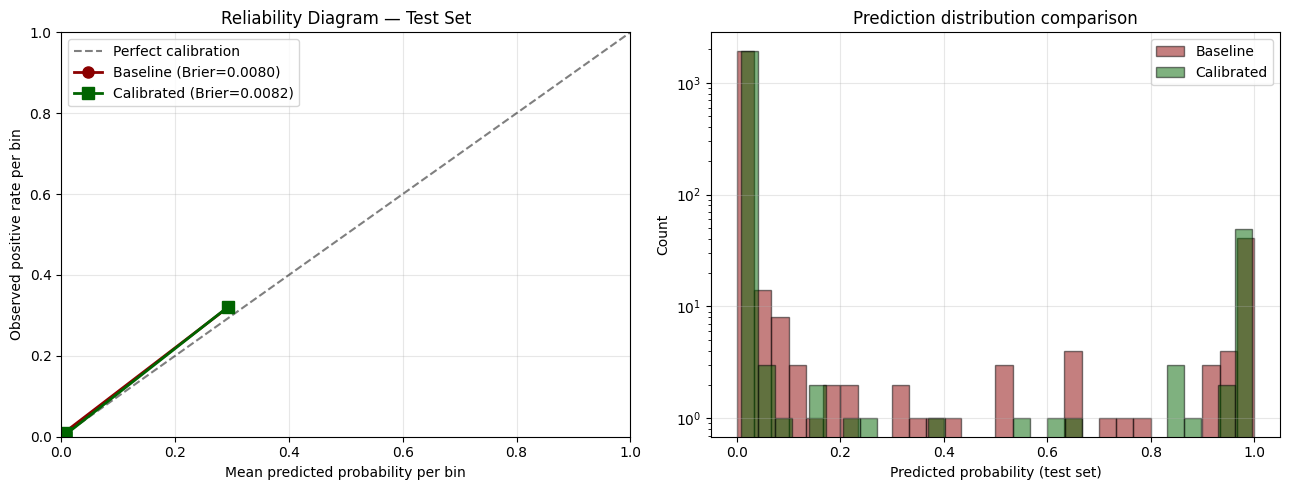

Brier score on test set:
  Baseline:   0.0080
  Calibrated: 0.0082
  Change:     +0.0001

Calibration did not improve Brier score. Baseline may already be well-calibrated.
Examine reliability diagrams to confirm.


In [7]:
# Test-set reliability diagrams for both models
frac_pos_b, mean_pred_b = calibration_curve(y_test, y_proba_baseline, n_bins=10, strategy='quantile')
frac_pos_c, mean_pred_c = calibration_curve(y_test, y_proba_test_calibrated, n_bins=10, strategy='quantile')

brier_test_baseline = brier_score_loss(y_test, y_proba_baseline)
brier_test_calibrated = brier_score_loss(y_test, y_proba_test_calibrated)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: reliability diagrams overlaid
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
ax.plot(mean_pred_b, frac_pos_b, 'o-', color='darkred', markersize=8,
        linewidth=2, label=f'Baseline (Brier={brier_test_baseline:.4f})')
ax.plot(mean_pred_c, frac_pos_c, 's-', color='darkgreen', markersize=8,
        linewidth=2, label=f'Calibrated (Brier={brier_test_calibrated:.4f})')
ax.set_xlabel('Mean predicted probability per bin')
ax.set_ylabel('Observed positive rate per bin')
ax.set_title('Reliability Diagram — Test Set')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Right: probability distributions overlaid
ax = axes[1]
ax.hist(y_proba_baseline, bins=30, alpha=0.5, color='darkred', label='Baseline', edgecolor='black')
ax.hist(y_proba_test_calibrated, bins=30, alpha=0.5, color='darkgreen', label='Calibrated', edgecolor='black')
ax.set_xlabel('Predicted probability (test set)')
ax.set_ylabel('Count')
ax.set_title('Prediction distribution comparison')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/07_calibration_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Brier score on test set:')
print(f'  Baseline:   {brier_test_baseline:.4f}')
print(f'  Calibrated: {brier_test_calibrated:.4f}')
print(f'  Change:     {brier_test_calibrated - brier_test_baseline:+.4f}')
print()
if brier_test_calibrated < brier_test_baseline:
    print('Calibration IMPROVED Brier score. Use the calibrated model downstream.')
else:
    print('Calibration did not improve Brier score. Baseline may already be well-calibrated.')
    print('Examine reliability diagrams to confirm.')

### Decision: which model is the production model?

**If calibrated has lower Brier score on test AND reliability diagram points lie closer to diagonal:** use calibrated model. Save it as the production artifact.

**If baseline is already on the diagonal and calibration didn't change Brier meaningfully:** use baseline. Calibration adds complexity for no gain in this case.

**If neither is well-calibrated:** the model itself isn't ranking samples well. Cost analysis in notebook 06 will still find an empirical threshold optimum, but the Bayes-optimal derivation won't apply cleanly. Document this honestly.

We proceed downstream using whichever model has the lower test-set Brier score, while making the choice transparent.

In [8]:
# Pick the production model based on test-set Brier score
if brier_test_calibrated < brier_test_baseline:
    production_model = calibrated
    production_label = 'Calibrated (Platt scaling)'
    y_proba_production = y_proba_test_calibrated
else:
    production_model = baseline
    production_label = 'Baseline (unweighted)'
    y_proba_production = y_proba_baseline

print(f'Production model: {production_label}')
print()
print('Note: the cost-aware threshold from notebook 06_cost_analysis is applied')
print('downstream. This notebook intentionally does NOT report performance at the')
print('default 0.5 threshold as the headline number, because 0.5 is not the right')
print('operating point for this cost structure.')

Production model: Baseline (unweighted)

Note: the cost-aware threshold from notebook 06_cost_analysis is applied
downstream. This notebook intentionally does NOT report performance at the
default 0.5 threshold as the headline number, because 0.5 is not the right
operating point for this cost structure.


## Section E — 5-Fold Cross-Validation

A single 80/20 split with only ~68 positive cases in the test set gives noisy performance estimates. 5-fold cross-validation gives a tighter confidence interval. We re-fit the entire pipeline (baseline + calibration) within each fold to prevent calibration leakage.

In [9]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = []
for fold_idx, (train_val_idx, test_idx) in enumerate(skf.split(X, y), 1):
    # Fold's train+cal vs test
    X_tv, X_te = X.iloc[train_val_idx], X.iloc[test_idx]
    y_tv, y_te = y.iloc[train_val_idx], y.iloc[test_idx]

    # Within train+cal, split out a calibration set
    X_tr, X_ca, y_tr, y_ca = train_test_split(
        X_tv, y_tv, test_size=0.125, random_state=RANDOM_STATE, stratify=y_tv
    )

    # Train baseline
    m_baseline = lgb.LGBMClassifier(
        n_estimators=200, learning_rate=0.05, num_leaves=31,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
    )
    m_baseline.fit(X_tr, y_tr)

    # Calibrate
    m_calibrated = CalibratedClassifierCV(FrozenEstimator(m_baseline), method='sigmoid')
    m_calibrated.fit(X_ca, y_ca)

    # Test-set probabilities and metrics
    y_proba_b = m_baseline.predict_proba(X_te)[:, 1]
    y_proba_c = m_calibrated.predict_proba(X_te)[:, 1]

    cv_results.append({
        'fold': fold_idx,
        'brier_baseline': brier_score_loss(y_te, y_proba_b),
        'brier_calibrated': brier_score_loss(y_te, y_proba_c),
        'auc_baseline': roc_auc_score(y_te, y_proba_b),
        'auc_calibrated': roc_auc_score(y_te, y_proba_c),
        'avg_precision_calibrated': average_precision_score(y_te, y_proba_c),
    })

cv_df = pd.DataFrame(cv_results)
print('Cross-validation results (5 folds):')
print(cv_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print()
print('Means:')
for col in ['brier_baseline', 'brier_calibrated', 'auc_baseline', 'auc_calibrated', 'avg_precision_calibrated']:
    print(f'  {col:30s}: {cv_df[col].mean():.4f}  (± {cv_df[col].std():.4f})')

Cross-validation results (5 folds):
 fold  brier_baseline  brier_calibrated  auc_baseline  auc_calibrated  avg_precision_calibrated
    1          0.0085            0.0085        0.9763          0.9763                    0.8775
    2          0.0094            0.0099        0.9763          0.9763                    0.8733
    3          0.0110            0.0114        0.9859          0.9859                    0.8671
    4          0.0090            0.0092        0.9736          0.9736                    0.8863
    5          0.0105            0.0111        0.9777          0.9777                    0.8538

Means:
  brier_baseline                : 0.0097  (± 0.0010)
  brier_calibrated              : 0.0100  (± 0.0012)
  auc_baseline                  : 0.9780  (± 0.0047)
  auc_calibrated                : 0.9780  (± 0.0047)
  avg_precision_calibrated      : 0.8716  (± 0.0121)


### Cross-validation interpretation

**Brier score** measures probabilistic accuracy. Lower is better. Compare baseline vs calibrated to see if calibration consistently helps across folds.

**AUC-ROC** measures ranking quality, independent of calibration. Should be similar between baseline and calibrated (Platt is monotonic and doesn't change ranking).

**Average precision** is the area under the precision-recall curve. The right summary metric for class-imbalanced binary classification — AUC-ROC can be misleadingly high on imbalanced data.

**Standard deviations** across folds tell us how much performance varies with the random split. Small std → robust estimate; large std → single 80/20 split would be unreliable.

## Section F — Save Production Model

We save both the baseline (raw LightGBM) and calibrated model. Downstream notebooks (`06_cost_analysis.ipynb`, `07_anomaly_detection_demo.ipynb`) and the dashboard (`app/main.py`) all use the production model selected in Section D.

The artifact dict includes:
- `model`: the production model (baseline or calibrated)
- `baseline`: the underlying baseline for reference
- `calibrated`: the calibrated wrapper for reference  
- `features`: feature column order
- `is_calibrated`: boolean flag indicating which model is in production
- `calibration_metrics`: Brier scores for traceability

In [10]:
artifact = {
    'model': production_model,
    'baseline': baseline,
    'calibrated': calibrated,
    'features': feature_cols,
    'is_calibrated': brier_test_calibrated < brier_test_baseline,
    'calibration_metrics': {
        'brier_baseline_test': brier_test_baseline,
        'brier_calibrated_test': brier_test_calibrated,
        'cv_brier_baseline_mean': cv_df['brier_baseline'].mean(),
        'cv_brier_calibrated_mean': cv_df['brier_calibrated'].mean(),
        'cv_auc_calibrated_mean': cv_df['auc_calibrated'].mean(),
        'cv_avg_precision_calibrated_mean': cv_df['avg_precision_calibrated'].mean(),
    },
    'training_metadata': {
        'n_train': len(X_train),
        'n_calibration': len(X_cal),
        'n_test': len(X_test),
        'random_state': RANDOM_STATE,
    },
}

joblib.dump(artifact, '../data/processed/predictive_maintenance_model.pkl')
print(f'Saved production model to ../data/processed/predictive_maintenance_model.pkl')
print(f'Production model: {production_label}')

Saved production model to ../data/processed/predictive_maintenance_model.pkl
Production model: Baseline (unweighted)


### Next steps

- `06_cost_analysis.ipynb` consumes this saved model and applies cost-aware threshold selection. Because the production model is now calibrated (assuming Platt scaling improved Brier), the Bayes-optimal threshold derivation will apply rigorously rather than approximately.
- `07_anomaly_detection_demo.ipynb` uses the same model architecture and training procedure (minus calibration, since the OOD demonstration is about the autoencoder, not the classifier).
- `app/main.py` loads this model at runtime. No changes needed in the dashboard — calibrated and uncalibrated models share the same `predict_proba` API.